# Phase 2.0 Leader Volume Overload

Notebook workflow for testing whether overloaded leader exposure can erode the `theta_T = 0.3` tolerance basin.

This notebook lets you vary both leader volume and leader direction.

- `LEADER_DIRECTION_MODE = "bimodal"`: keep the original two-sided leader setup.
- `LEADER_DIRECTION_MODE = "positive"`: force all leaders to the positive side.
- `LEADER_DIRECTION_MODE = "negative"`: force all leaders to the negative side.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

os.environ.setdefault("MPLCONFIGDIR", "/tmp/opinion_abm_mpl")

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'main.py').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import DEFAULT_SEED, make_notebook_baseline_params
from initialization import initialize_model
from main import run_one_round
from metrics import format_round_summary
from utils import ensure_directory, project_path, set_random_seed


In [2]:
SEED = DEFAULT_SEED
ROUNDS = 50
THETA_T = 0.3
LEADER_WEIGHT = 10.0
LEADER_DIRECTION_MODE = "positive"  # options: "bimodal", "positive", "negative"
OUTPUT_SUBDIR_ROOT = "phase2_leader_volume_overload_notebook"


In [3]:
def _ratio(numerator, denominator):
    if denominator <= 0:
        return 0.0
    return float(numerator / denominator)


def apply_leader_direction(agents, leader_direction_mode):
    agents = agents.copy()
    leader_mask = agents["L"] == 1

    if leader_direction_mode == "bimodal":
        return agents
    if leader_direction_mode == "positive":
        agents.loc[leader_mask, "o_t"] = agents.loc[leader_mask, "o_t"].abs()
        agents.loc[leader_mask, "s_t"] = 1
        return agents
    if leader_direction_mode == "negative":
        agents.loc[leader_mask, "o_t"] = -agents.loc[leader_mask, "o_t"].abs()
        agents.loc[leader_mask, "s_t"] = -1
        return agents

    raise ValueError(
        f"Unsupported LEADER_DIRECTION_MODE={leader_direction_mode!r}. "
        "Use 'bimodal', 'positive', or 'negative'."
    )


def build_zone_record(round_number, agents, params, initial_in_zone_nonleaders):
    theta_t = float(params["tolerance_threshold"])
    in_zone_mask = agents["o_t"].abs() < theta_t
    nonleader_mask = agents["L"] == 0
    leader_mask = ~nonleader_mask

    current_nonleader_in_zone_nodes = set(
        agents.loc[in_zone_mask & nonleader_mask, "node"].astype(int).tolist()
    )
    initial_survivors = initial_in_zone_nonleaders & current_nonleader_in_zone_nodes
    escaped_from_initial = initial_in_zone_nonleaders - current_nonleader_in_zone_nodes

    total_in_zone = int(in_zone_mask.sum())
    total_nonleaders = int(nonleader_mask.sum())
    total_leaders = int(leader_mask.sum())
    nonleader_in_zone = int((in_zone_mask & nonleader_mask).sum())
    leader_in_zone = int((in_zone_mask & leader_mask).sum())

    return {
        "round": int(round_number),
        "tolerance_threshold": theta_t,
        "total_agents": int(len(agents)),
        "total_leaders": total_leaders,
        "total_nonleaders": total_nonleaders,
        "in_zone_total_count": total_in_zone,
        "in_zone_total_ratio": _ratio(total_in_zone, len(agents)),
        "in_zone_nonleader_count": nonleader_in_zone,
        "in_zone_nonleader_ratio": _ratio(nonleader_in_zone, total_nonleaders),
        "in_zone_leader_count": leader_in_zone,
        "in_zone_leader_ratio": _ratio(leader_in_zone, total_leaders),
        "out_zone_nonleader_count": int(total_nonleaders - nonleader_in_zone),
        "out_zone_nonleader_ratio": _ratio(total_nonleaders - nonleader_in_zone, total_nonleaders),
        "initial_in_zone_nonleader_count": int(len(initial_in_zone_nonleaders)),
        "initial_in_zone_survivor_count": int(len(initial_survivors)),
        "initial_in_zone_survivor_ratio": _ratio(len(initial_survivors), len(initial_in_zone_nonleaders)),
        "initial_in_zone_escape_count": int(len(escaped_from_initial)),
        "initial_in_zone_escape_ratio": _ratio(len(escaped_from_initial), len(initial_in_zone_nonleaders)),
        "mean_tau_in_zone_nonleaders": float(
            agents.loc[in_zone_mask & nonleader_mask, "tau_t"].mean()
        ) if nonleader_in_zone > 0 else 0.0,
        "mean_tau_out_zone_nonleaders": float(
            agents.loc[(~in_zone_mask) & nonleader_mask, "tau_t"].mean()
        ) if nonleader_in_zone < total_nonleaders else 0.0,
    }


def summarize_zone_shift(zone_df):
    if zone_df.empty:
        return pd.DataFrame()

    start = zone_df.iloc[0]
    end = zone_df.iloc[-1]
    return pd.DataFrame([
        {
            "rounds": int(end["round"]),
            "theta_T": float(end["tolerance_threshold"]),
            "initial_in_zone_nonleader_count": int(start["in_zone_nonleader_count"]),
            "final_in_zone_nonleader_count": int(end["in_zone_nonleader_count"]),
            "delta_in_zone_nonleader_count": int(end["in_zone_nonleader_count"] - start["in_zone_nonleader_count"]),
            "initial_in_zone_nonleader_ratio": float(start["in_zone_nonleader_ratio"]),
            "final_in_zone_nonleader_ratio": float(end["in_zone_nonleader_ratio"]),
            "delta_in_zone_nonleader_ratio": float(end["in_zone_nonleader_ratio"] - start["in_zone_nonleader_ratio"]),
            "final_survivor_count": int(end["initial_in_zone_survivor_count"]),
            "final_survivor_ratio": float(end["initial_in_zone_survivor_ratio"]),
            "final_escape_count": int(end["initial_in_zone_escape_count"]),
            "final_escape_ratio": float(end["initial_in_zone_escape_ratio"]),
            "min_in_zone_nonleader_count": int(zone_df["in_zone_nonleader_count"].min()),
            "min_in_zone_nonleader_round": int(zone_df.loc[zone_df["in_zone_nonleader_count"].idxmin(), "round"]),
            "max_escape_ratio": float(zone_df["initial_in_zone_escape_ratio"].max()),
            "max_escape_ratio_round": int(zone_df.loc[zone_df["initial_in_zone_escape_ratio"].idxmax(), "round"]),
        }
    ])


def run_notebook_experiment(rounds, seed, tolerance_threshold, leader_weight, leader_direction_mode, output_subdir_root):
    params = make_notebook_baseline_params({
        "T_rounds": int(rounds),
        "tolerance_threshold": float(tolerance_threshold),
        "w_l": float(leader_weight),
    })

    rng = set_random_seed(seed)
    graph, _, agents, blocks, _ = initialize_model(params, seed=seed)
    agents = apply_leader_direction(agents, leader_direction_mode)

    leader_df = agents.loc[agents["L"] == 1, ["node", "o_t", "tau_t", "F_t"]].copy()
    leader_summary = pd.DataFrame([
        {
            "leader_direction_mode": leader_direction_mode,
            "leader_count": int(len(leader_df)),
            "positive_leader_count": int((leader_df["o_t"] > 0).sum()),
            "negative_leader_count": int((leader_df["o_t"] < 0).sum()),
            "mean_leader_opinion": float(leader_df["o_t"].mean()) if not leader_df.empty else 0.0,
            "mean_abs_leader_opinion": float(leader_df["o_t"].abs().mean()) if not leader_df.empty else 0.0,
        }
    ])

    theta_t = float(params["tolerance_threshold"])
    initial_in_zone_nonleaders = set(
        agents.loc[(agents["L"] == 0) & (agents["o_t"].abs() < theta_t), "node"].astype(int).tolist()
    )

    zone_records = [
        build_zone_record(
            round_number=0,
            agents=agents,
            params=params,
            initial_in_zone_nonleaders=initial_in_zone_nonleaders,
        )
    ]
    round_records = []

    for round_number in range(1, params["T_rounds"] + 1):
        graph, agents, posts, exposure_sets, summary = run_one_round(
            graph,
            agents,
            blocks,
            params,
            rng,
            current_round=round_number,
        )
        summary["round"] = round_number
        round_records.append(summary)
        print(format_round_summary(round_number, summary))

        zone_records.append(
            build_zone_record(
                round_number=round_number,
                agents=agents,
                params=params,
                initial_in_zone_nonleaders=initial_in_zone_nonleaders,
            )
        )

    history_df = pd.DataFrame(round_records)
    zone_df = pd.DataFrame(zone_records).sort_values("round").reset_index(drop=True)
    summary_df = summarize_zone_shift(zone_df)

    output_subdir = f"{output_subdir_root}_{leader_direction_mode}_wl{leader_weight:g}_theta{tolerance_threshold:g}"
    output_dir = ensure_directory(project_path("outputs", output_subdir))
    history_df.to_csv(output_dir / "history.csv", index=False)
    zone_df.to_csv(output_dir / "tolerance_zone_counts.csv", index=False)
    summary_df.to_csv(output_dir / "tolerance_zone_summary.csv", index=False)
    leader_df.to_csv(output_dir / "leaders_after_direction_override.csv", index=False)
    leader_summary.to_csv(output_dir / "leader_direction_summary.csv", index=False)

    manifest_df = pd.DataFrame([
        {
            "phase": "phase2_leader_volume_overload_notebook",
            "seed": int(seed),
            "rounds": int(rounds),
            "tolerance_threshold": float(tolerance_threshold),
            "leader_weight": float(leader_weight),
            "leader_direction_mode": leader_direction_mode,
            "baseline": "make_notebook_baseline_params",
        }
    ])
    manifest_df.to_csv(output_dir / "experiment_manifest.csv", index=False)

    return {
        "params": params,
        "history_df": history_df,
        "zone_df": zone_df,
        "summary_df": summary_df,
        "leader_df": leader_df,
        "leader_summary": leader_summary,
        "output_dir": output_dir,
    }


In [4]:
results = run_notebook_experiment(
    rounds=ROUNDS,
    seed=SEED,
    tolerance_threshold=THETA_T,
    leader_weight=LEADER_WEIGHT,
    leader_direction_mode=LEADER_DIRECTION_MODE,
    output_subdir_root=OUTPUT_SUBDIR_ROOT,
)

zone_df = results["zone_df"]
summary_df = results["summary_df"]
history_df = results["history_df"]
leader_df = results["leader_df"]
leader_summary = results["leader_summary"]
output_dir = results["output_dir"]

display(leader_summary)
display(summary_df)
display(zone_df.head())
display(zone_df.tail())
output_dir


Round 01 | Creators=127 | Support= 56 | Oppose= 71 | Toxic= 64 | AvgExposure=7.74 | Edges=3074
Round 02 | Creators=149 | Support= 85 | Oppose= 64 | Toxic=128 | AvgExposure=8.47 | Edges=3079
Round 03 | Creators=107 | Support= 51 | Oppose= 56 | Toxic=104 | AvgExposure=6.22 | Edges=3066
Round 04 | Creators=117 | Support= 51 | Oppose= 66 | Toxic=115 | AvgExposure=10.27 | Edges=3081
Round 05 | Creators= 52 | Support= 26 | Oppose= 26 | Toxic= 52 | AvgExposure=4.07 | Edges=3073
Round 06 | Creators= 90 | Support= 45 | Oppose= 45 | Toxic= 88 | AvgExposure=6.87 | Edges=3075
Round 07 | Creators= 92 | Support= 45 | Oppose= 47 | Toxic= 91 | AvgExposure=6.45 | Edges=3070
Round 08 | Creators= 68 | Support= 36 | Oppose= 32 | Toxic= 67 | AvgExposure=4.32 | Edges=3048
Round 09 | Creators= 78 | Support= 41 | Oppose= 37 | Toxic= 76 | AvgExposure=8.25 | Edges=3071
Round 10 | Creators= 44 | Support= 30 | Oppose= 14 | Toxic= 44 | AvgExposure=5.17 | Edges=3097
Round 11 | Creators= 45 | Support= 22 | Oppose= 2

,leader_direction_mode,leader_count,positive_leader_count,negative_leader_count,mean_leader_opinion,mean_abs_leader_opinion
0,bimodal,16,6,10,-0.187802,0.734423


,rounds,theta_T,initial_in_zone_nonleader_count,final_in_zone_nonleader_count,delta_in_zone_nonleader_count,initial_in_zone_nonleader_ratio,final_in_zone_nonleader_ratio,delta_in_zone_nonleader_ratio,final_survivor_count,final_survivor_ratio,final_escape_count,final_escape_ratio,min_in_zone_nonleader_count,min_in_zone_nonleader_round,max_escape_ratio,max_escape_ratio_round
0,50,0.3,444,562,118,0.45122,0.571138,0.119919,299,0.673423,145,0.326577,444,0,0.326577,49


,round,tolerance_threshold,total_agents,total_leaders,total_nonleaders,in_zone_total_count,in_zone_total_ratio,in_zone_nonleader_count,in_zone_nonleader_ratio,in_zone_leader_count,in_zone_leader_ratio,out_zone_nonleader_count,out_zone_nonleader_ratio,initial_in_zone_nonleader_count,initial_in_zone_survivor_count,initial_in_zone_survivor_ratio,initial_in_zone_escape_count,initial_in_zone_escape_ratio,mean_tau_in_zone_nonleaders,mean_tau_out_zone_nonleaders
0,0,0.3,1000,16,984,444,0.444,444,0.451220,0,0.0,540,0.548780,444,444,1.000000,0,0.000000,1.969206,2.003589
1,1,0.3,1000,16,984,522,0.522,522,0.530488,0,0.0,462,0.469512,444,420,0.945946,24,0.054054,2.275746,2.442769
2,2,0.3,1000,16,984,518,0.518,518,0.526423,0,0.0,466,0.473577,444,404,0.909910,40,0.090090,1.968739,2.121709
3,3,0.3,1000,16,984,529,0.529,529,0.537602,0,0.0,455,0.462398,444,411,0.925676,33,0.074324,1.840311,1.979161
4,4,0.3,1000,16,984,524,0.524,524,0.532520,0,0.0,460,0.467480,444,393,0.885135,51,0.114865,1.402440,1.532892


,round,tolerance_threshold,total_agents,total_leaders,total_nonleaders,in_zone_total_count,in_zone_total_ratio,in_zone_nonleader_count,in_zone_nonleader_ratio,in_zone_leader_count,in_zone_leader_ratio,out_zone_nonleader_count,out_zone_nonleader_ratio,initial_in_zone_nonleader_count,initial_in_zone_survivor_count,initial_in_zone_survivor_ratio,initial_in_zone_escape_count,initial_in_zone_escape_ratio,mean_tau_in_zone_nonleaders,mean_tau_out_zone_nonleaders
46,46,0.3,1000,16,984,567,0.567,567,0.576220,0,0.0,417,0.423780,444,304,0.684685,140,0.315315,3.452727,3.613421
47,47,0.3,1000,16,984,566,0.566,566,0.575203,0,0.0,418,0.424797,444,301,0.677928,143,0.322072,3.596281,3.821268
48,48,0.3,1000,16,984,567,0.567,567,0.576220,0,0.0,417,0.423780,444,301,0.677928,143,0.322072,3.363876,3.625598
49,49,0.3,1000,16,984,562,0.562,562,0.571138,0,0.0,422,0.428862,444,299,0.673423,145,0.326577,3.762855,3.981225
50,50,0.3,1000,16,984,562,0.562,562,0.571138,0,0.0,422,0.428862,444,299,0.673423,145,0.326577,4.105516,4.356902


PosixPath('/Users/paimon/projects/Opinion_ABM/outputs/phase2_leader_volume_overload_notebook_bimodal_wl20_theta0.3')

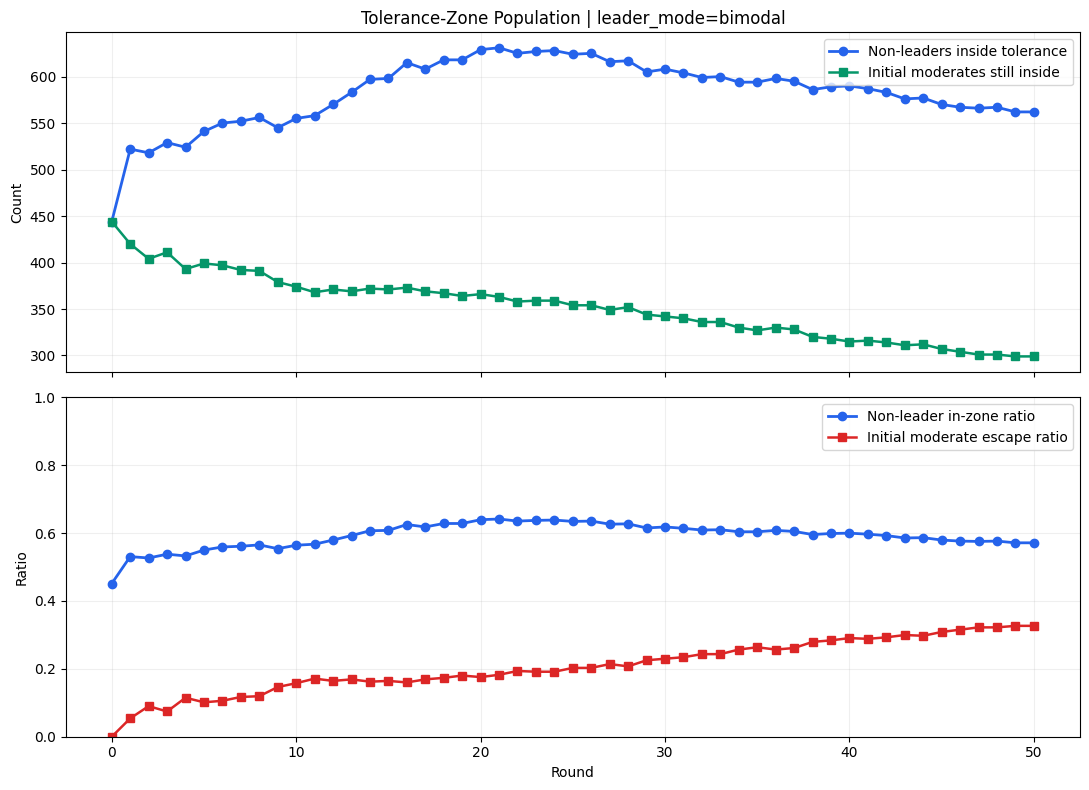

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].plot(
    zone_df["round"],
    zone_df["in_zone_nonleader_count"],
    marker="o",
    linewidth=2.0,
    color="#2563eb",
    label="Non-leaders inside tolerance",
)
axes[0].plot(
    zone_df["round"],
    zone_df["initial_in_zone_survivor_count"],
    marker="s",
    linewidth=1.8,
    color="#059669",
    label="Initial moderates still inside",
)
axes[0].set_ylabel("Count")
axes[0].set_title(f"Tolerance-Zone Population | leader_mode={LEADER_DIRECTION_MODE}")
axes[0].grid(alpha=0.2)
axes[0].legend(loc="best")

axes[1].plot(
    zone_df["round"],
    zone_df["in_zone_nonleader_ratio"],
    marker="o",
    linewidth=2.0,
    color="#2563eb",
    label="Non-leader in-zone ratio",
)
axes[1].plot(
    zone_df["round"],
    zone_df["initial_in_zone_escape_ratio"],
    marker="s",
    linewidth=1.8,
    color="#dc2626",
    label="Initial moderate escape ratio",
)
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Ratio")
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(alpha=0.2)
axes[1].legend(loc="best")

fig.tight_layout()
plt.show()


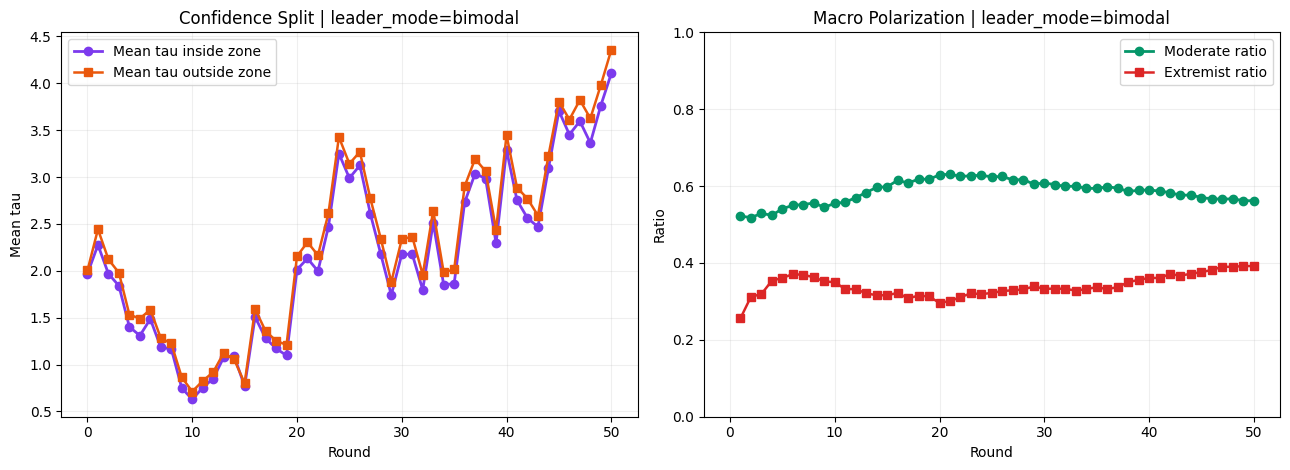

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)

axes[0].plot(
    zone_df["round"],
    zone_df["mean_tau_in_zone_nonleaders"],
    marker="o",
    linewidth=2.0,
    color="#7c3aed",
    label="Mean tau inside zone",
)
axes[0].plot(
    zone_df["round"],
    zone_df["mean_tau_out_zone_nonleaders"],
    marker="s",
    linewidth=1.8,
    color="#ea580c",
    label="Mean tau outside zone",
)
axes[0].set_title(f"Confidence Split | leader_mode={LEADER_DIRECTION_MODE}")
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Mean tau")
axes[0].grid(alpha=0.2)
axes[0].legend(loc="best")

axes[1].plot(
    history_df["round"],
    history_df["moderate_ratio"],
    marker="o",
    linewidth=2.0,
    color="#059669",
    label="Moderate ratio",
)
axes[1].plot(
    history_df["round"],
    history_df["extremist_ratio"],
    marker="s",
    linewidth=1.8,
    color="#dc2626",
    label="Extremist ratio",
)
axes[1].set_title(f"Macro Polarization | leader_mode={LEADER_DIRECTION_MODE}")
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Ratio")
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(alpha=0.2)
axes[1].legend(loc="best")

fig.tight_layout()
plt.show()


In [7]:
print(f"Saved CSV/figures to: {output_dir}")
print(output_dir / "experiment_manifest.csv")
print(output_dir / "leader_direction_summary.csv")
print(output_dir / "tolerance_zone_counts.csv")
print(output_dir / "tolerance_zone_summary.csv")


Saved CSV/figures to: /Users/paimon/projects/Opinion_ABM/outputs/phase2_leader_volume_overload_notebook_bimodal_wl20_theta0.3
/Users/paimon/projects/Opinion_ABM/outputs/phase2_leader_volume_overload_notebook_bimodal_wl20_theta0.3/experiment_manifest.csv
/Users/paimon/projects/Opinion_ABM/outputs/phase2_leader_volume_overload_notebook_bimodal_wl20_theta0.3/leader_direction_summary.csv
/Users/paimon/projects/Opinion_ABM/outputs/phase2_leader_volume_overload_notebook_bimodal_wl20_theta0.3/tolerance_zone_counts.csv
/Users/paimon/projects/Opinion_ABM/outputs/phase2_leader_volume_overload_notebook_bimodal_wl20_theta0.3/tolerance_zone_summary.csv
